In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

import joblib
import os

In [2]:
df_emp = pd.read_csv("../data/raw/employee_management_dataset.csv")

df_emp.head()

,day_of_week,transactions,total_quantity,staff_needed
0,6,70,252,8
1,3,100,107,8
2,4,24,264,5
3,6,48,75,4
4,2,23,275,6


In [3]:
df_emp.describe()

,day_of_week,transactions,total_quantity,staff_needed
count,1000.0000,1000.000000,1000.00000,1000.000000
mean,2.9600,68.805000,171.60500,6.691000
std,2.0036,29.203181,72.36131,2.073118
min,0.0000,20.000000,50.00000,2.000000
25%,1.0000,44.000000,108.75000,5.000000
50%,3.0000,68.000000,173.00000,7.000000
75%,5.0000,93.000000,234.00000,8.000000
max,6.0000,119.000000,299.00000,10.000000


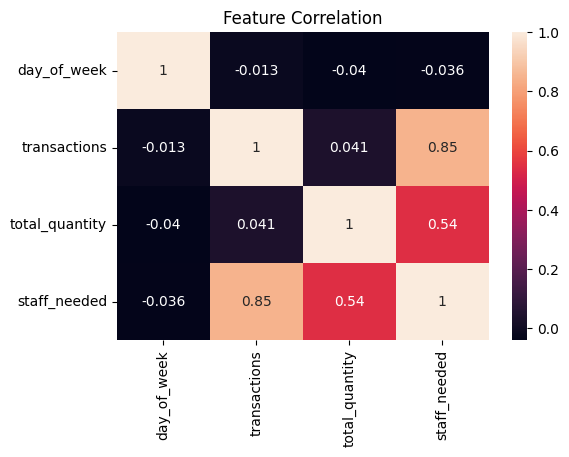

In [4]:
plt.figure(figsize=(6,4))

sns.heatmap(df_emp.corr(), annot=True)

plt.title("Feature Correlation")

plt.show()

In [5]:
X = df_emp[["day_of_week","transactions","total_quantity"]]

y = df_emp["staff_needed"]

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [7]:
model_emp = RandomForestRegressor()

model_emp.fit(X_train, y_train)

RandomForestRegressor()

In [8]:
pred = model_emp.predict(X_test)

print("R2 Score:", r2_score(y_test, pred))

print("RMSE:", np.sqrt(mean_squared_error(y_test, pred)))

R2 Score: 0.982983371040724
RMSE: 0.27425079762873983


In [9]:
sample = [[2,70,180]]

prediction = model_emp.predict(sample)

print("Staff Needed:", round(prediction[0]))

Staff Needed: 7


C:\Users\farma\OneDrive\Desktop\Brainybeam\PharmaEase\venv\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


In [10]:
import joblib
import os

os.makedirs("models", exist_ok=True)

joblib.dump(model_emp,"../models/staff_model.pkl")

['../models/staff_model.pkl']

In [19]:
import joblib
import os

os.makedirs("models", exist_ok=True)

joblib.dump(model_emp,"../models/staff_model.pkl")

['../models/staff_model.pkl']